# Multimodal Emotion Recognizer — Fusão Gated Reliability (com Ablation Study)

Notebook de treino/avaliação da fusão multimodal compacta (adapters por modalidade → confiabilidade → interações pareadas → MLP).
Os backbones (BERT / Wav2Vec2 / VideoMAE) já foram aplicados e congelados no pré-processamento;
aqui consumimos os embeddings em cache.

**Todo o comportamento é controlado por 4 variáveis** (célula de Configuração):
`dataset` (pt/en), `grid_search`, `bit_mask` e `modals`. Habilite/desabilite qualquer
modalidade sem tocar no restante do código, e alterne entre os caches PT e EN de forma transparente.

> Adaptável a CPU, CUDA/NVIDIA e DirectML/AMD. Mixed precision fica ativo apenas em CUDA. Com as 3 modalidades
> ligadas, `bit_mask=False` e `grid_search=False`, o comportamento é equivalente ao notebook original.

## 1. Configuração

As quatro variáveis abaixo controlam completamente o notebook.

In [1]:
# ===================== CONTROLE DO EXPERIMENTO =====================
dataset         = "pt"    # "pt" ou "en"  -> monta o caminho do cache
resume_emotions = True    # True: agrupa as 7 emoções em 3 classes de valência (neg/neutro/pos)
class_weighting = True    # CrossEntropyLoss ponderada por classe (inverso da freq.) p/ desbalanceamento
grid_search     = True   # False: 1 treino por combinação | True: grid search por combinação
bit_mask        = True    # True: roda TODAS as combinações de modalidades (001..111)
                          # False: usa exatamente o dicionário 'modals' abaixo

modals = {
    "text":   True,
    "audio":  True,
    "images": True,
}
# ==================================================================

In [2]:
# Hiperparâmetros do modelo/treino (Seções 6, 7, 9 e 10 do documento de arquitetura)
CONFIG = {
    # arquitetura de fusão compacta (adequada aos 599 exemplos e embeddings globais)
    "embed_dim":   192,
    "num_heads":   8,
    "ff_dim":      1024,
    "dropout":     0.25,
    "num_layers":  4,
    "modality_dropout": 0.15,  # torna a fusão robusta a uma modalidade pouco confiável
    "num_classes": 7,
    # dimensão de entrada por modalidade (todas 768 no cache atual)
    "in_dims":     {"text": 768, "audio": 768, "images": 768},
    # treino
    "batch_size":   32,
    "epochs":       60,
    "lr":           3e-4,
    "weight_decay": 1e-2,
    "grad_clip":    1.0,
    "patience":     12,      # early stopping (0 desativa)
    "num_workers":  0,       # 0 = mais seguro no Windows/Colab
    "cache_tensors_on_device": True,  # embeddings cabem na VRAM e evitam copia CPU->GPU por batch
    # split estratificado
    "val_ratio":  0.15,
    "test_ratio": 0.15,
    "seed":       42,
}

# Espaço e configurações do grid search (usados só quando grid_search=True)
SEARCH_SPACE = {
    "embed_dim":         [160, 192, 224],
    "dropout":           [0.15, 0.25, 0.35],
    "modality_dropout": [0.0, 0.15, 0.25],
    "lr":           [1e-3, 3e-4, 1e-4],
    "weight_decay": [1e-2, 1e-3, 1e-4],
    "batch_size":   [16, 32, 64],
    "num_layers":  [2, 3, 4],
}
GS_MODE       = "random" # "grid" (completo) ou "random"
GS_N_ITER     = 24       # nº de combinações no modo "random"
GS_MAX_TRIALS = None     # limita trials no modo "grid" (None = todos)

# DirectML/AMD fica estavel com uma unica execucao por vez. A GPU paraleliza os kernels internamente.
GRIDSEARCH_WORKERS = 1
BITMASK_WORKERS    = 1
GS_EPOCHS     = 30       # épocas por trial (com early stopping)
GS_PATIENCE   = 8        # paciência do early stopping dentro de cada trial

# --- Constantes de modalidade (extensível: acrescente entradas aqui) ---
MODALITIES  = ["text", "audio", "images"]                       # ordem canônica dos tokens
CACHE_FIELD = {"text": "text", "audio": "audio", "images": "image"}  # chave no .pt do cache
# Emoções originais (7 classes), na ordem do label_id
EMOTION_NAMES_7 = ["Anger", "Disgust", "Fear", "Happy", "Neutral", "Sadness", "Surprised"]

# Agrupamento por valência (usado quando resume_emotions=True):
#   -1 negativo | 0 neutro | +1 positivo   (chave = label_id original 0..6)
EMOTION_VALENCE = {
    0: -1,  # Anger     -> negativo
    1: -1,  # Disgust   -> negativo
    2: -1,  # Fear      -> negativo
    3:  1,  # Happy     -> positivo
    4:  0,  # Neutral   -> neutro
    5: -1,  # Sadness   -> negativo
    6:  1,  # Surprised -> positivo   (valência debatível; mova para 0 p/ tratar como neutro)
}

if resume_emotions:
    LABEL_NAMES = ["Negative", "Neutral", "Positive"]   # índices 0,1,2 <=> valência -1,0,+1
    CONFIG["num_classes"] = 3
else:
    LABEL_NAMES = EMOTION_NAMES_7
    CONFIG["num_classes"] = 7
assert len(LABEL_NAMES) == CONFIG["num_classes"]


def remap_label(label_id):
    """label_id original (0..6) -> índice de classe do experimento (0..num_classes-1)."""
    if resume_emotions:
        return EMOTION_VALENCE[int(label_id)] + 1   # {-1,0,1} -> {0,1,2}
    return int(label_id)

# --- Caminhos derivados de 'dataset' (nada hardcoded) ---
CACHE_DIR      = f"../cache_{dataset}_v2/multimodal"
CHECKPOINT_DIR = f"../checkpoints/{dataset}"

## 2. Imports

In [3]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Dependências (descomente no Google Colab):
# %pip install torch torch-directml torchmetrics scikit-learn matplotlib pandas tqdm

import os
import glob
import random
import copy
import itertools
import collections
import contextlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm


def set_seed(seed: int):
    """Fixa as seeds para reprodutibilidade (Seção 15)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

try:
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass  # Jupyter pode impedir alterar interop threads depois que o runtime ja iniciou.

# Adaptável a CUDA/NVIDIA, DirectML/AMD e CPU
device = torch.device("cpu")
DEVICE_BACKEND = "cpu"
DEVICE_NAME = "CPU"

if torch.cuda.is_available():
    device = torch.device("cuda")
    DEVICE_BACKEND = "cuda"
    DEVICE_NAME = torch.cuda.get_device_name(0)
else:
    try:
        import torch_directml
        device = torch_directml.device()
        DEVICE_BACKEND = "directml"
        DEVICE_NAME = "GPU AMD/DirectML"
    except Exception as exc:
        print(f"DirectML indisponivel ({exc}) -> usando CPU. Para AMD, instale torch-directml e reinicie o kernel.")

IS_ACCELERATOR = DEVICE_BACKEND in {"cuda", "directml"}
USE_AMP = DEVICE_BACKEND == "cuda"  # DirectML ainda nao suporta autocast/GradScaler CUDA.
PIN_MEMORY = DEVICE_BACKEND == "cuda"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def to_device_tensor(x):
    if getattr(x, "device", None) == device:
        return x
    kwargs = {"non_blocking": True} if DEVICE_BACKEND == "cuda" else {}
    return x.to(device, **kwargs)

def autocast_context():
    return torch.amp.autocast(device_type="cuda", enabled=True) if USE_AMP else contextlib.nullcontext()

def clear_device_cache():
    if DEVICE_BACKEND == "cuda":
        torch.cuda.empty_cache()

print(f"PyTorch {torch.__version__} | backend: {DEVICE_BACKEND} | device: {device} | AMP: {USE_AMP}")
print("Acelerador:", DEVICE_NAME)

DirectML indisponivel (DLL load failed while importing torch_directml_native: Não foi possível encontrar o procedimento especificado.) -> usando CPU. Para AMD, instale torch-directml e reinicie o kernel.
PyTorch 2.7.1+cpu | backend: cpu | device: cpu | AMP: False
Acelerador: CPU


c:\Users\luis-\Documents\codigos\academico\MultimodalEmotionReconizer\.venv-torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Dependências (descomente no Google Colab):
# %pip install torch torch-directml torchmetrics scikit-learn matplotlib pandas tqdm

import os
import glob
import random
import copy
import itertools
import collections
import contextlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm


def set_seed(seed: int):
    """Fixa as seeds para reprodutibilidade (Seção 15)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

try:
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass  # Jupyter pode impedir alterar interop threads depois que o runtime ja iniciou.

# Adaptável a CUDA/NVIDIA, DirectML/AMD e CPU
device = torch.device("cpu")
DEVICE_BACKEND = "cpu"
DEVICE_NAME = "CPU"

if torch.cuda.is_available():
    device = torch.device("cuda")
    DEVICE_BACKEND = "cuda"
    DEVICE_NAME = torch.cuda.get_device_name(0)
else:
    try:
        import torch_directml
        device = torch_directml.device()
        DEVICE_BACKEND = "directml"
        DEVICE_NAME = "GPU AMD/DirectML"
    except Exception as exc:
        print(f"DirectML indisponivel ({exc}) -> usando CPU. Para AMD, instale torch-directml e reinicie o kernel.")

IS_ACCELERATOR = DEVICE_BACKEND in {"cuda", "directml"}
USE_AMP = DEVICE_BACKEND == "cuda"  # DirectML ainda nao suporta autocast/GradScaler CUDA.
PIN_MEMORY = DEVICE_BACKEND == "cuda"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def to_device_tensor(x):
    if getattr(x, "device", None) == device:
        return x
    kwargs = {"non_blocking": True} if DEVICE_BACKEND == "cuda" else {}
    return x.to(device, **kwargs)

def autocast_context():
    return torch.amp.autocast(device_type="cuda", enabled=True) if USE_AMP else contextlib.nullcontext()

def clear_device_cache():
    if DEVICE_BACKEND == "cuda":
        torch.cuda.empty_cache()

print(f"PyTorch {torch.__version__} | backend: {DEVICE_BACKEND} | device: {device} | AMP: {USE_AMP}")
print("Acelerador:", DEVICE_NAME)

DirectML indisponivel (DLL load failed while importing torch_directml_native: Não foi possível encontrar o procedimento especificado.) -> usando CPU. Para AMD, instale torch-directml e reinicie o kernel.
PyTorch 2.7.1+cpu | backend: cpu | device: cpu | AMP: False
Acelerador: CPU


## 3. Dataset

Carrega os embeddings em cache **uma única vez** e mantém em RAM apenas as modalidades
que serão usadas (as desativadas nunca são carregadas). O `Dataset` devolve somente as
modalidades ativas — portanto elas nunca entram no batch nem no modelo (sem placeholders/zeros).

In [6]:
# ------------------- Modalidades ativas / plano de experimentos -------------------
def get_active_modalities(mask_dict):
    """Lista de modalidades ligadas, na ordem canônica."""
    return [m for m in MODALITIES if mask_dict.get(m, False)]

def all_modality_combos():
    """Todos os subconjuntos não-vazios de modalidades (001..111)."""
    combos = []
    for r in range(1, len(MODALITIES) + 1):
        combos += [list(c) for c in itertools.combinations(MODALITIES, r)]
    return combos

def modality_mask_str(active):
    """String de bits na ordem canônica, ex.: text+images -> '101'."""
    return "".join("1" if m in active else "0" for m in MODALITIES)

def modality_label(active):
    return "+".join(active) if active else "(nenhuma)"

# bit_mask e modals definem QUAIS combinações rodar
if bit_mask:
    combos_to_run = all_modality_combos()
else:
    _active = get_active_modalities(modals)
    assert _active, "Nenhuma modalidade habilitada em 'modals' (com bit_mask=False)."
    combos_to_run = [_active]

# só carrega do cache as modalidades que aparecem em alguma combinação
modalities_used = [m for m in MODALITIES if any(m in c for c in combos_to_run)]

print(f"dataset={dataset} | grid_search={grid_search} | bit_mask={bit_mask}")
print(f"Cache: {CACHE_DIR}")
print(f"Combinações a rodar ({len(combos_to_run)}):")
for c in combos_to_run:
    print(f"   [{modality_mask_str(c)}] {modality_label(c)}")
print(f"Modalidades carregadas em RAM: {modalities_used}")

dataset=pt | grid_search=True | bit_mask=True
Cache: ../cache_pt_v2/multimodal
Combinações a rodar (7):
   [100] text
   [010] audio
   [001] images
   [110] text+audio
   [101] text+images
   [011] audio+images
   [111] text+audio+images
Modalidades carregadas em RAM: ['text', 'audio', 'images']


In [7]:
def load_raw_samples(cache_dir, keep_modalities):
    """Lê todos os .pt uma vez, mantendo em RAM só as modalidades necessárias + label."""
    files = sorted(glob.glob(os.path.join(cache_dir, "*.pt")))
    if not files:
        raise RuntimeError(
            f"Nenhum .pt em {cache_dir}. Verifique a variável 'dataset' e se o cache "
            f"correspondente (cache_{dataset}) já foi gerado."
        )
    fields = [CACHE_FIELD[m] for m in keep_modalities]
    raw = []
    for fp in files:
        s = torch.load(fp, map_location="cpu")
        item = {f: s[f].float() for f in fields}
        item["label"] = remap_label(s["label"])
        raw.append(item)
    return files, raw


class MultimodalEmotionDataset(Dataset):
    """Devolve apenas as modalidades ativas (chaveadas pelo nome da modalidade)."""

    def __init__(self, raw_samples, active_modalities):
        self.raw = raw_samples
        self.active = list(active_modalities)

    def __len__(self):
        return len(self.raw)

    def __getitem__(self, idx):
        s = self.raw[idx]
        item = {m: s[CACHE_FIELD[m]] for m in self.active}   # só as ativas entram no batch
        item["label"] = torch.as_tensor(s["label"], dtype=torch.long)
        return item


RAW_FILES, RAW_SAMPLES = load_raw_samples(CACHE_DIR, modalities_used)
LABELS_ALL = np.asarray([s["label"] for s in RAW_SAMPLES], dtype=np.int64)

def infer_and_apply_input_dims(raw_samples, keep_modalities):
    inferred = {m: int(raw_samples[0][CACHE_FIELD[m]].shape[-1]) for m in keep_modalities}
    for i, sample in enumerate(raw_samples):
        for m in keep_modalities:
            field = CACHE_FIELD[m]
            got = int(sample[field].shape[-1])
            if got != inferred[m]:
                raise ValueError(f"Dimensao inconsistente em {m}: amostra 0 tem {inferred[m]}, amostra {i} tem {got}")
    CONFIG["in_dims"].update(inferred)
    return inferred

INFERRED_IN_DIMS = infer_and_apply_input_dims(RAW_SAMPLES, modalities_used)

def cache_raw_tensors_on_accelerator(raw_samples, keep_modalities):
    if not (CONFIG.get("cache_tensors_on_device", False) and IS_ACCELERATOR):
        return False
    for sample in raw_samples:
        for m in keep_modalities:
            field = CACHE_FIELD[m]
            sample[field] = to_device_tensor(sample[field])
    return True

CACHE_TENSORS_ON_ACCELERATOR = cache_raw_tensors_on_accelerator(RAW_SAMPLES, modalities_used)
print(f"Amostras carregadas: {len(RAW_SAMPLES)}")
print("Dimensoes inferidas do cache:", INFERRED_IN_DIMS)
print(f"Embeddings em {DEVICE_BACKEND}: {CACHE_TENSORS_ON_ACCELERATOR}")

# validação de shapes (Seção 15)
_s0 = RAW_SAMPLES[0]
for m in modalities_used:
    got = _s0[CACHE_FIELD[m]].shape[-1]
    assert got == CONFIG["in_dims"][m], f"{m}: esperado {CONFIG['in_dims'][m]}, obtido {got}"
print("Shapes:", {m: tuple(_s0[CACHE_FIELD[m]].shape) for m in modalities_used})

_dist = collections.Counter(LABELS_ALL.tolist())
print("Classes:", {LABEL_NAMES[c]: _dist.get(c, 0) for c in range(CONFIG["num_classes"])})

Amostras carregadas: 604
Dimensoes inferidas do cache: {'text': 1539, 'audio': 1536, 'images': 1536}
Embeddings em cpu: False
Shapes: {'text': (1539,), 'audio': (1536,), 'images': (1536,)}
Classes: {'Negative': 336, 'Neutral': 93, 'Positive': 175}


## 4. DataLoader

Split estratificado **70/15/15** (com seed), calculado uma única vez e reaproveitado por
todas as combinações de modalidades — garantindo comparação justa na ablação.

In [8]:
def stratified_split(labels, val_ratio, test_ratio, seed):
    idx = np.arange(len(labels))
    temp = val_ratio + test_ratio
    train_idx, tmp_idx = train_test_split(idx, test_size=temp, stratify=labels, random_state=seed)
    val_idx, test_idx = train_test_split(
        tmp_idx, test_size=test_ratio / temp, stratify=labels[tmp_idx], random_state=seed
    )
    return train_idx, val_idx, test_idx


SPLIT_IDX = stratified_split(LABELS_ALL, CONFIG["val_ratio"], CONFIG["test_ratio"], CONFIG["seed"])
print(f"Split -> treino {len(SPLIT_IDX[0])} | val {len(SPLIT_IDX[1])} | teste {len(SPLIT_IDX[2])}")


def move_batch(batch, active):
    """Move ao device apenas as modalidades ativas + o alvo."""
    inputs = {m: to_device_tensor(batch[m]) for m in active}
    target = to_device_tensor(batch["label"])
    return inputs, target


def make_loaders(raw_samples, active, batch_size, split_idx):
    ds = MultimodalEmotionDataset(raw_samples, active)
    g = torch.Generator().manual_seed(CONFIG["seed"])
    num_workers = 0 if CACHE_TENSORS_ON_ACCELERATOR else CONFIG["num_workers"]
    pin = PIN_MEMORY and not CACHE_TENSORS_ON_ACCELERATOR
    train = DataLoader(Subset(ds, split_idx[0]), batch_size=batch_size, shuffle=True,
                       num_workers=num_workers, generator=g, pin_memory=pin)
    val   = DataLoader(Subset(ds, split_idx[1]), batch_size=batch_size, shuffle=False,
                       num_workers=num_workers, pin_memory=pin)
    test  = DataLoader(Subset(ds, split_idx[2]), batch_size=batch_size, shuffle=False,
                       num_workers=num_workers, pin_memory=pin)
    return train, val, test

def compute_class_weights(num_classes):
    """Pesos por classe (inverso da frequência, estilo 'balanced') a partir do split de treino."""
    train_labels = LABELS_ALL[SPLIT_IDX[0]]
    counts = np.bincount(train_labels, minlength=num_classes).astype(np.float64)
    weights = counts.sum() / (num_classes * np.maximum(counts, 1.0))
    return torch.tensor(weights, dtype=torch.float32, device=device)


_counts = np.bincount(LABELS_ALL[SPLIT_IDX[0]], minlength=CONFIG["num_classes"])
_cw = compute_class_weights(CONFIG["num_classes"])
print("Contagem por classe (treino):",
      {LABEL_NAMES[c]: int(_counts[c]) for c in range(CONFIG["num_classes"])})
print("Pesos de classe:",
      {LABEL_NAMES[c]: round(float(_cw[c]), 3) for c in range(CONFIG["num_classes"])},
      "| aplicados na loss:", class_weighting)

Split -> treino 422 | val 91 | teste 91
Contagem por classe (treino): {'Negative': 235, 'Neutral': 65, 'Positive': 122}
Pesos de classe: {'Negative': 0.599, 'Neutral': 2.164, 'Positive': 1.153} | aplicados na loss: True


## 5. Modelo

Projeções, embedding de modalidade e fusão são criados **apenas para as modalidades ativas**.
Os tokens são construídos dinamicamente e o Transformer recebe só os tokens existentes.
Para adicionar uma nova modalidade no futuro, basta acrescentá-la em `MODALITIES`,
`CACHE_FIELD` e `CONFIG["in_dims"]`.

In [9]:
class MeanPooling(nn.Module):
    """Média sobre os tokens de modalidade: [B, T, E] -> [B, E]."""
    def forward(self, x):
        return x.mean(dim=1)


class EmotionMLP(nn.Module):
    """Cabeça de classificação (Seção 9): embed_dim -> 256 -> 128 -> n_classes."""
    def __init__(self, embed_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.net(x)


class MultimodalEncoder(nn.Module):
    """Projeta cada modalidade ativa para embed_dim e as funde por self-attention.

    Constrói dinamicamente:
        tokens = [proj_m(x_m) + emb_m  para cada modalidade ativa]
        x = stack(tokens, dim=1)   # [B, n_ativas, E]
    """
    def __init__(self, cfg, active_modalities):
        super().__init__()
        E = cfg["embed_dim"]
        self.active = list(active_modalities)

        # uma projeção e um embedding de modalidade por modalidade ATIVA
        self.proj = nn.ModuleDict({m: nn.Linear(cfg["in_dims"][m], E) for m in self.active})
        self.modality_emb = nn.ParameterDict({m: nn.Parameter(torch.zeros(1, E)) for m in self.active})
        for p in self.modality_emb.values():
            nn.init.trunc_normal_(p, std=0.02)

        self.dropout = nn.Dropout(cfg["dropout"])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=E, nhead=cfg["num_heads"], dim_feedforward=cfg["ff_dim"],
            dropout=cfg["dropout"], batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=cfg["num_layers"])

    def forward(self, inputs):
        # ordem canônica preservada (self.active já vem ordenado)
        tokens = [self.proj[m](inputs[m]) + self.modality_emb[m] for m in self.active]  # cada [B, E]
        x = torch.stack(tokens, dim=1)     # [B, n_ativas, E]
        x = self.dropout(x)
        return self.encoder(x)             # [B, n_ativas, E]


class MultimodalEmotionClassifier(nn.Module):
    def __init__(self, cfg, active_modalities):
        super().__init__()
        self.active  = list(active_modalities)
        self.encoder = MultimodalEncoder(cfg, active_modalities)
        self.pool    = MeanPooling()
        self.head    = EmotionMLP(cfg["embed_dim"], cfg["num_classes"])

    def forward(self, inputs):
        x = self.encoder(inputs)   # [B, n_ativas, E]
        x = self.pool(x)           # [B, E]
        return self.head(x)        # [B, n_classes]


def build_model(active, cfg):
    return MultimodalEmotionClassifier(cfg, active).to(device)


# Demonstração de shape/params com a 1ª combinação a rodar
_demo = build_model(combos_to_run[0], CONFIG)
_n = sum(p.numel() for p in _demo.parameters() if p.requires_grad)
print(f"Modelo p/ [{modality_mask_str(combos_to_run[0])}] {modality_label(combos_to_run[0])}"
      f" | params treináveis: {_n:,}")
del _demo

Modelo p/ [100] text | params treináveis: 2,552,259


### Fusão proposta: adapters + confiabilidade + interações pareadas

O cache atual contém **um vetor global por modalidade**, não sequências. Portanto, um Transformer profundo sobre apenas 1–3 tokens tem poucos padrões relacionais para aprender e muitos parâmetros para 599 amostras. A célula abaixo substitui a fusão por uma arquitetura menor e alinhada a essa informação: (1) adapters residuais normalizam cada espaço pré-treinado; (2) um gate aprende a confiabilidade por exemplo; (3) produtos e diferenças pares capturam complementaridade/conflito entre modalidades; (4) logits unimodais entram como ensemble residual. Durante treino, modality dropout evita dependência rígida de uma única fonte.

A implementação mantém a mesma interface, os mesmos caches e a ablação; por isso a comparação com a execução anterior é direta.

In [10]:
def norm_layer(num_features):
    # DirectML falha no backward do nn.LayerNorm em alguns drivers/versoes.
    return nn.Identity() if DEVICE_BACKEND == "directml" else nn.LayerNorm(num_features)


class ModalityAdapter(nn.Module):
    """Adapta um embedding congelado sem descartar sua projeção linear de origem."""
    def __init__(self, in_dim, embed_dim, dropout):
        super().__init__()
        bottleneck = max(64, embed_dim // 2)
        self.skip = nn.Linear(in_dim, embed_dim, bias=False)
        self.adapter = nn.Sequential(norm_layer(in_dim), nn.Linear(in_dim, bottleneck), nn.GELU(), nn.Dropout(dropout), nn.Linear(bottleneck, embed_dim))
        self.norm = norm_layer(embed_dim)

    def forward(self, x):
        return self.norm(self.skip(x) + self.adapter(x))


class ReliabilityGatedFusion(nn.Module):
    """Fusão tardia compacta para embeddings globais de texto, áudio e vídeo."""
    def __init__(self, cfg, active_modalities):
        super().__init__()
        self.active = list(active_modalities)
        self.n_modalities = len(self.active)
        self.embed_dim = cfg['embed_dim']
        self.modality_dropout = cfg.get('modality_dropout', 0.0)
        E, C, D = self.embed_dim, cfg['num_classes'], cfg['dropout']
        self.adapters = nn.ModuleDict({m: ModalityAdapter(cfg['in_dims'][m], E, D) for m in self.active})
        self.reliability = nn.Sequential(nn.Linear(E * self.n_modalities, E), norm_layer(E), nn.GELU(), nn.Dropout(D), nn.Linear(E, self.n_modalities))
        self.pairs = [(a, b) for i, a in enumerate(self.active) for b in self.active[i + 1:]]
        self.interactions = nn.ModuleDict({f'{a}_{b}': nn.Sequential(nn.Linear(2 * E, E), nn.GELU(), nn.Dropout(D), norm_layer(E)) for a, b in self.pairs})
        fusion_in = E * (1 + len(self.pairs))
        self.fusion = nn.Sequential(nn.Linear(fusion_in, E), nn.GELU(), nn.Dropout(D), norm_layer(E))
        self.head = nn.Sequential(nn.Linear(E, E // 2), nn.GELU(), nn.Dropout(D), nn.Linear(E // 2, C))
        self.unimodal_heads = nn.ModuleDict({m: nn.Linear(E, C) for m in self.active})

    def forward(self, inputs):
        reps = torch.stack([self.adapters[m](inputs[m]) for m in self.active], dim=1)
        gate_logits = self.reliability(reps.flatten(start_dim=1))
        if self.training and self.n_modalities > 1 and self.modality_dropout > 0:
            keep = torch.rand(reps.shape[:2], device=reps.device) > self.modality_dropout
            empty = ~keep.any(dim=1)
            keep[empty, 0] = True
            gate_logits = gate_logits.masked_fill(~keep, -1e4)
        weights = torch.softmax(gate_logits, dim=1)
        weighted = (weights.unsqueeze(-1) * reps).sum(dim=1)
        pairwise = [self.interactions[f'{a}_{b}'](torch.cat([reps[:, self.active.index(a)] * reps[:, self.active.index(b)], (reps[:, self.active.index(a)] - reps[:, self.active.index(b)]).abs()], dim=-1)) for a, b in self.pairs]
        fused = self.fusion(torch.cat([weighted] + pairwise, dim=-1))
        expert_logits = torch.stack([self.unimodal_heads[m](reps[:, i]) for i, m in enumerate(self.active)], dim=1)
        return self.head(fused) + (weights.unsqueeze(-1) * expert_logits).sum(dim=1)


class MultimodalEmotionClassifier(ReliabilityGatedFusion):
    pass


def build_model(active, cfg):
    return MultimodalEmotionClassifier(cfg, active).to(device)


_demo = build_model(combos_to_run[0], CONFIG)
_n = sum(p.numel() for p in _demo.parameters() if p.requires_grad)
print(f'Fusao gated p/ [{modality_mask_str(combos_to_run[0])}] {modality_label(combos_to_run[0])} | params treinaveis: {_n:,}')
del _demo

Fusao gated p/ [100] text | params treinaveis: 559,885


## 6. Treinamento

Engine reutilizável: `train_model` treina uma combinação de modalidades com uma dada
config, faz validação a cada época, aplica early stopping, guarda o melhor estado e
(opcionalmente) salva o checkpoint. Usado tanto pelo treino único quanto pelo grid search.

In [11]:
def compute_metrics(y_true, y_pred, num_classes):
    labels = list(range(num_classes))
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )
    return {"acc": accuracy_score(y_true, y_pred), "precision": prec, "recall": rec, "f1_macro": f1}


def cpu_state_dict(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


@torch.no_grad()
def run_eval(model, loader, active, criterion=None):
    model.eval()
    total_loss, preds, truths = 0.0, [], []
    for batch in loader:
        inputs, target = move_batch(batch, active)
        with autocast_context():
            logits = model(inputs)
            if criterion is not None:
                total_loss += criterion(logits, target).item() * target.size(0)
        preds.append(logits.argmax(1).cpu())
        truths.append(target.cpu())
    truths_cat = torch.cat(truths)
    avg = total_loss / len(truths_cat) if criterion is not None else None
    return avg, torch.cat(preds).numpy(), truths_cat.numpy()


def train_one_epoch(model, loader, active, criterion, optimizer, scaler):
    model.train()
    total_loss, preds, truths = 0.0, [], []
    for batch in loader:
        inputs, target = move_batch(batch, active)
        with autocast_context():
            logits = model(inputs)
            loss = criterion(logits, target)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * target.size(0)
        preds.append(logits.argmax(1).detach().cpu())
        truths.append(target.detach().cpu())
    truths_cat = torch.cat(truths)
    return total_loss / len(truths_cat), torch.cat(preds).numpy(), truths_cat.numpy()


def train_model(active, cfg, epochs, patience, ckpt_path=None, verbose=True):
    """Treina uma combinação de modalidades. Retorna o modelo no melhor estado + histórico."""
    set_seed(cfg["seed"])
    model = build_model(active, cfg)
    class_weight = compute_class_weights(cfg["num_classes"]) if class_weighting else None
    criterion = nn.CrossEntropyLoss(weight=class_weight)
    optimizer_kwargs = {"foreach": False} if DEVICE_BACKEND == "directml" else {}
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"], **optimizer_kwargs)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler(enabled=USE_AMP)
    train_loader, val_loader, _ = make_loaders(RAW_SAMPLES, active, cfg["batch_size"], SPLIT_IDX)

    history = {k: [] for k in
               ["train_loss", "val_loss", "train_acc", "val_acc", "train_f1", "val_f1", "lr"]}
    best = {"f1": -1.0, "acc": 0.0, "epoch": -1, "state": None}
    no_improve = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_pred, tr_true = train_one_epoch(model, train_loader, active, criterion, optimizer, scaler)
        scheduler.step()
        va_loss, va_pred, va_true = run_eval(model, val_loader, active, criterion)

        trm = compute_metrics(tr_true, tr_pred, cfg["num_classes"])
        vam = compute_metrics(va_true, va_pred, cfg["num_classes"])
        lr_now = optimizer.param_groups[0]["lr"]
        for k, v in zip(history, [tr_loss, va_loss, trm["acc"], vam["acc"], trm["f1_macro"], vam["f1_macro"], lr_now]):
            history[k].append(v)

        if vam["f1_macro"] > best["f1"]:
            best = {"f1": vam["f1_macro"], "acc": vam["acc"], "epoch": epoch,
                    "state": cpu_state_dict(model)}
            no_improve = 0
        else:
            no_improve += 1

        if verbose:
            print(f"[{epoch:02d}/{epochs}] train f1 {trm['f1_macro']:.4f} | "
                  f"val loss {va_loss:.4f} acc {vam['acc']:.4f} f1 {vam['f1_macro']:.4f} | lr {lr_now:.2e}")
        if patience and no_improve >= patience:
            if verbose:
                print(f"Early stopping na época {epoch}.")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    if ckpt_path:
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
        torch.save({
            "model_state":      cpu_state_dict(model),
            "config":           cfg,
            "active_modalities": active,
            "dataset":          dataset,
            "label_names":      LABEL_NAMES,
            "epoch":            best["epoch"],
            "val_f1_macro":     best["f1"],
            "val_acc":          best["acc"],
        }, ckpt_path)

    return {"model": model, "history": history,
            "best_val_f1": best["f1"], "best_val_acc": best["acc"], "best_epoch": best["epoch"]}

## 7. Validação

A validação ocorre a cada época dentro de `train_model` (early stopping por F1-macro de
validação). Aqui ficam os utilitários de métricas/curvas usados na validação e no relatório.

In [12]:
def plot_history(history, title=""):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (a, b, t) in zip(axes, [
        ("train_loss", "val_loss", "Loss"),
        ("train_acc",  "val_acc",  "Accuracy"),
        ("train_f1",   "val_f1",   "F1-macro"),
    ]):
        ax.plot(ep, history[a], label="treino")
        ax.plot(ep, history[b], label="val")
        ax.set_title(t); ax.set_xlabel("época"); ax.legend()
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 8. Teste

Avaliação no conjunto de teste (isolado do treino/validação) para um modelo já treinado.

In [13]:
def evaluate_on_test(model, active, batch_size):
    _, _, test_loader = make_loaders(RAW_SAMPLES, active, batch_size, SPLIT_IDX)
    _, y_pred, y_true = run_eval(model, test_loader, active, criterion=None)
    return compute_metrics(y_true, y_pred, CONFIG["num_classes"]), y_true, y_pred


def plot_confusion(y_true, y_pred, class_names, title=""):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 9. Grid Search

Busca de hiperparâmetros para uma combinação de modalidades. Reaproveita `train_model`.
Controlada pela variável `grid_search`. Agnóstica ao device (usa AMP e libera VRAM entre trials).

In [14]:
def run_grid_trial(active, hp):
    cfg = {**CONFIG, "in_dims": dict(CONFIG["in_dims"]), **hp}
    fit = train_model(active, cfg, GS_EPOCHS, GS_PATIENCE, ckpt_path=None, verbose=False)
    record = {**hp, "val_f1_macro": fit["best_val_f1"],
              "val_acc": fit["best_val_acc"], "best_epoch": fit["best_epoch"]}
    del fit
    clear_device_cache()
    return record


def run_grid_search(active, tag):
    keys = list(SEARCH_SPACE.keys())
    all_c = [dict(zip(keys, v)) for v in itertools.product(*[SEARCH_SPACE[k] for k in keys])]
    valid = all_c  # a fusão gated não usa a restrição embed_dim/número de heads
    if GS_MODE == "random":
        combos = random.Random(CONFIG["seed"]).sample(valid, min(GS_N_ITER, len(valid)))
    else:
        combos = valid if GS_MAX_TRIALS is None else valid[:GS_MAX_TRIALS]
    print(f"  grid search [{tag}]: {len(combos)} trials (de {len(valid)} válidas)")

    print(f"  workers grid search [{tag}]: 1")
    records = [run_grid_trial(active, hp) for hp in tqdm(combos, desc=f"GS[{tag}]", leave=False)]

    results_df = (pd.DataFrame(records)
                  .sort_values("val_f1_macro", ascending=False, na_position="last")
                  .reset_index(drop=True))
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    results_df.to_csv(os.path.join(CHECKPOINT_DIR, f"gridsearch_{tag}.csv"), index=False)

    # retreina a melhor config (mais épocas) e salva o checkpoint
    best_hp = {k: (float(results_df.iloc[0][k]) if k in ("lr", "weight_decay", "dropout", "modality_dropout")
                   else int(results_df.iloc[0][k])) for k in SEARCH_SPACE}
    best_cfg = {**CONFIG, "in_dims": dict(CONFIG["in_dims"]), **best_hp}
    fit = train_model(active, best_cfg, max(CONFIG["epochs"], GS_EPOCHS), CONFIG["patience"],
                      ckpt_path=os.path.join(CHECKPOINT_DIR, f"best_gridsearch_{tag}.pt"), verbose=False)
    return {"model": fit["model"], "history": fit["history"], "best_cfg": best_cfg,
            "results_df": results_df, "val_f1_macro": float(results_df.iloc[0]["val_f1_macro"])}

## 10. Resultados

Orquestra tudo a partir das 4 variáveis de configuração: para cada combinação de
modalidades treina (ou roda o grid search), avalia no teste, e ao final consolida a
comparação de ablação (tabela + gráficos + matrizes de confusão).

In [15]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
experiment_results, detailed = [], {}
print("Workers bitmask search: 1")

for active in combos_to_run:
    mask, name = modality_mask_str(active), modality_label(active)
    tag = f"{dataset}_{mask}"
    print(f"\n{'=' * 64}\n>> Modalidades: {name}  [{mask}]  | dataset={dataset} | grid_search={grid_search}\n{'=' * 64}")

    if grid_search:
        out = run_grid_search(active, tag)
        model, used_cfg = out["model"], out["best_cfg"]
        val_f1, history = out["val_f1_macro"], out["history"]
        print("  melhor config:", {k: used_cfg[k] for k in SEARCH_SPACE})
    else:
        out = train_model(active, CONFIG, CONFIG["epochs"], CONFIG["patience"],
                          ckpt_path=os.path.join(CHECKPOINT_DIR, f"best_{tag}.pt"), verbose=True)
        model, used_cfg = out["model"], CONFIG
        val_f1, history = out["best_val_f1"], out["history"]

    tm, y_true, y_pred = evaluate_on_test(model, active, used_cfg["batch_size"])
    print(f"  [TESTE] acc {tm['acc']:.4f} | P {tm['precision']:.4f} | R {tm['recall']:.4f} | F1-macro {tm['f1_macro']:.4f}")
    print(classification_report(y_true, y_pred, labels=list(range(CONFIG["num_classes"])),
                                target_names=LABEL_NAMES, zero_division=0))

    experiment_results.append({
        "dataset": dataset, "modalities": name, "mask": mask,
        "val_f1_macro": round(float(val_f1), 4), "test_acc": round(tm["acc"], 4),
        "test_precision": round(tm["precision"], 4), "test_recall": round(tm["recall"], 4),
        "test_f1_macro": round(tm["f1_macro"], 4),
    })
    detailed[mask] = {"name": name, "history": history, "y_true": y_true, "y_pred": y_pred}

    del model
    clear_device_cache()

print("\nExperimentos concluídos.")

Workers bitmask search: 1

>> Modalidades: text  [100]  | dataset=pt | grid_search=True
  grid search [pt_100]: 24 trials (de 2187 válidas)
  workers grid search [pt_100]: 1


  melhor config: {'embed_dim': 224, 'dropout': 0.25, 'modality_dropout': 0.15, 'lr': 0.0001, 'weight_decay': 0.01, 'batch_size': 32, 'num_layers': 2}
  [TESTE] acc 0.6044 | P 0.5567 | R 0.5448 | F1-macro 0.5496
              precision    recall  f1-score   support

    Negative       0.71      0.71      0.71        51
     Neutral       0.50      0.43      0.46        14
    Positive       0.46      0.50      0.48        26

    accuracy                           0.60        91
   macro avg       0.56      0.54      0.55        91
weighted avg       0.61      0.60      0.60        91


>> Modalidades: audio  [010]  | dataset=pt | grid_search=True
  grid search [pt_010]: 24 trials (de 2187 válidas)
  workers grid search [pt_010]: 1


  melhor config: {'embed_dim': 160, 'dropout': 0.25, 'modality_dropout': 0.25, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 64, 'num_layers': 2}
  [TESTE] acc 0.4505 | P 0.3833 | R 0.4313 | F1-macro 0.3962
              precision    recall  f1-score   support

    Negative       0.58      0.57      0.57        51
     Neutral       0.35      0.57      0.43        14
    Positive       0.22      0.15      0.18        26

    accuracy                           0.45        91
   macro avg       0.38      0.43      0.40        91
weighted avg       0.44      0.45      0.44        91


>> Modalidades: images  [001]  | dataset=pt | grid_search=True
  grid search [pt_001]: 24 trials (de 2187 válidas)
  workers grid search [pt_001]: 1


  melhor config: {'embed_dim': 192, 'dropout': 0.25, 'modality_dropout': 0.15, 'lr': 0.0001, 'weight_decay': 0.0001, 'batch_size': 16, 'num_layers': 3}
  [TESTE] acc 0.6264 | P 0.5983 | R 0.6129 | F1-macro 0.5942
              precision    recall  f1-score   support

    Negative       0.79      0.61      0.69        51
     Neutral       0.50      0.50      0.50        14
    Positive       0.50      0.73      0.59        26

    accuracy                           0.63        91
   macro avg       0.60      0.61      0.59        91
weighted avg       0.67      0.63      0.63        91


>> Modalidades: text+audio  [110]  | dataset=pt | grid_search=True
  grid search [pt_110]: 24 trials (de 2187 válidas)
  workers grid search [pt_110]: 1


  melhor config: {'embed_dim': 192, 'dropout': 0.15, 'modality_dropout': 0.25, 'lr': 0.0001, 'weight_decay': 0.01, 'batch_size': 64, 'num_layers': 3}
  [TESTE] acc 0.6484 | P 0.6030 | R 0.6134 | F1-macro 0.6051
              precision    recall  f1-score   support

    Negative       0.78      0.69      0.73        51
     Neutral       0.50      0.50      0.50        14
    Positive       0.53      0.65      0.59        26

    accuracy                           0.65        91
   macro avg       0.60      0.61      0.61        91
weighted avg       0.66      0.65      0.65        91


>> Modalidades: text+images  [101]  | dataset=pt | grid_search=True
  grid search [pt_101]: 24 trials (de 2187 válidas)
  workers grid search [pt_101]: 1


  melhor config: {'embed_dim': 160, 'dropout': 0.15, 'modality_dropout': 0.15, 'lr': 0.0003, 'weight_decay': 0.001, 'batch_size': 32, 'num_layers': 4}
  [TESTE] acc 0.6044 | P 0.5689 | R 0.5935 | F1-macro 0.5713
              precision    recall  f1-score   support

    Negative       0.77      0.59      0.67        51
     Neutral       0.44      0.50      0.47        14
    Positive       0.50      0.69      0.58        26

    accuracy                           0.60        91
   macro avg       0.57      0.59      0.57        91
weighted avg       0.64      0.60      0.61        91


>> Modalidades: audio+images  [011]  | dataset=pt | grid_search=True
  grid search [pt_011]: 24 trials (de 2187 válidas)
  workers grid search [pt_011]: 1


  melhor config: {'embed_dim': 192, 'dropout': 0.25, 'modality_dropout': 0.15, 'lr': 0.0001, 'weight_decay': 0.0001, 'batch_size': 16, 'num_layers': 3}
  [TESTE] acc 0.6264 | P 0.5998 | R 0.5893 | F1-macro 0.5845
              precision    recall  f1-score   support

    Negative       0.77      0.65      0.70        51
     Neutral       0.55      0.43      0.48        14
    Positive       0.49      0.69      0.57        26

    accuracy                           0.63        91
   macro avg       0.60      0.59      0.58        91
weighted avg       0.65      0.63      0.63        91


>> Modalidades: text+audio+images  [111]  | dataset=pt | grid_search=True
  grid search [pt_111]: 24 trials (de 2187 válidas)
  workers grid search [pt_111]: 1


  melhor config: {'embed_dim': 224, 'dropout': 0.35, 'modality_dropout': 0.15, 'lr': 0.0003, 'weight_decay': 0.001, 'batch_size': 64, 'num_layers': 4}
  [TESTE] acc 0.6593 | P 0.6369 | R 0.6372 | F1-macro 0.6320
              precision    recall  f1-score   support

    Negative       0.80      0.69      0.74        51
     Neutral       0.62      0.57      0.59        14
    Positive       0.50      0.65      0.57        26

    accuracy                           0.66        91
   macro avg       0.64      0.64      0.63        91
weighted avg       0.68      0.66      0.67        91


Experimentos concluídos.


In [16]:
# Tabela de comparação (ablação), ordenada pelo F1-macro de teste
results_table = (pd.DataFrame(experiment_results)
                 .sort_values("test_f1_macro", ascending=False)
                 .reset_index(drop=True))
_csv = os.path.join(CHECKPOINT_DIR, f"ablation_results_{dataset}.csv")
results_table.to_csv(_csv, index=False)
print(f"Resultados salvos em: {_csv}")
results_table

Resultados salvos em: ../checkpoints/pt\ablation_results_pt.csv


,dataset,modalities,mask,val_f1_macro,test_acc,test_precision,test_recall,test_f1_macro
0,pt,text+audio+images,111,0.7068,0.6593,0.6369,0.6372,0.6320
1,pt,text+audio,110,0.5667,0.6484,0.6030,0.6134,0.6051
2,pt,images,001,0.7007,0.6264,0.5983,0.6129,0.5942
3,pt,audio+images,011,0.7357,0.6264,0.5998,0.5893,0.5845
4,pt,text+images,101,0.7053,0.6044,0.5689,0.5935,0.5713
5,pt,text,100,0.5397,0.6044,0.5567,0.5448,0.5496
6,pt,audio,010,0.6012,0.4505,0.3833,0.4313,0.3962


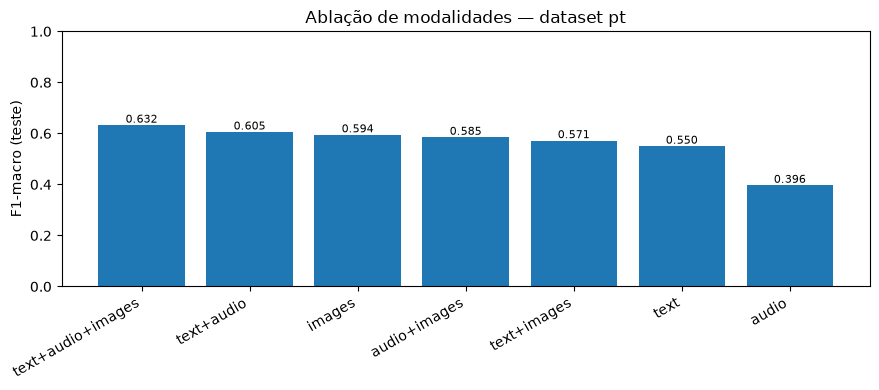

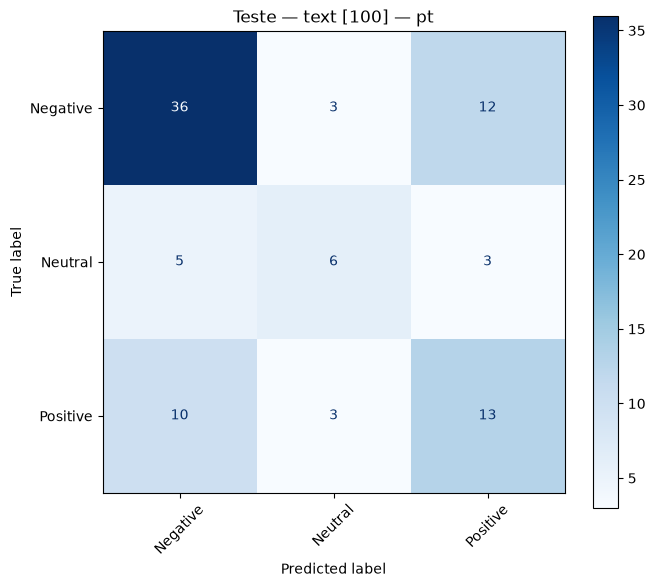

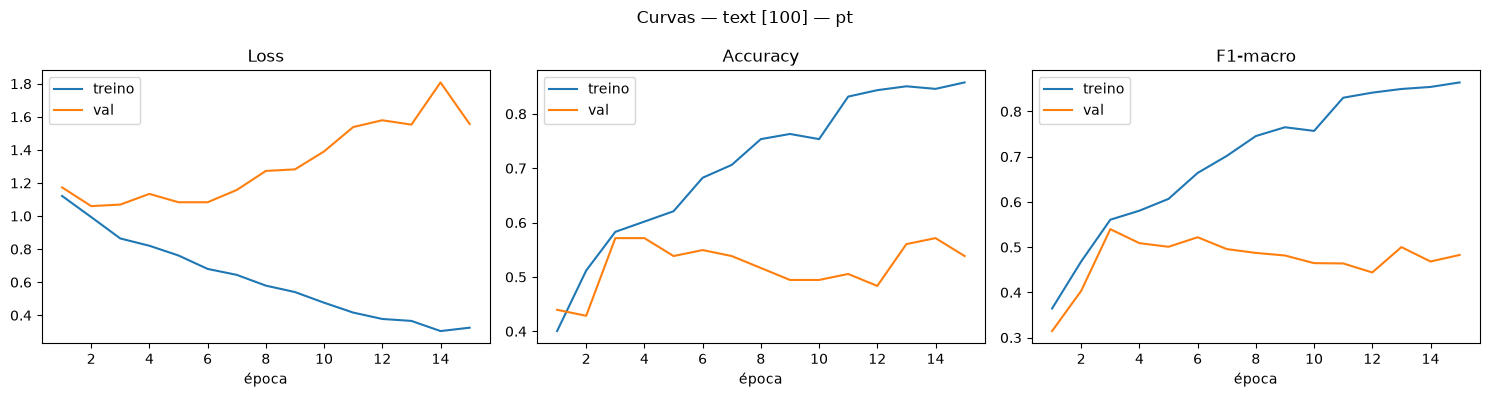

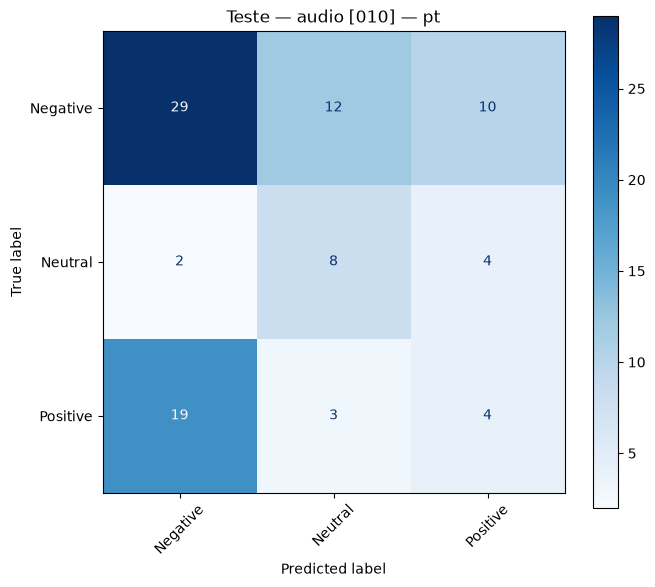

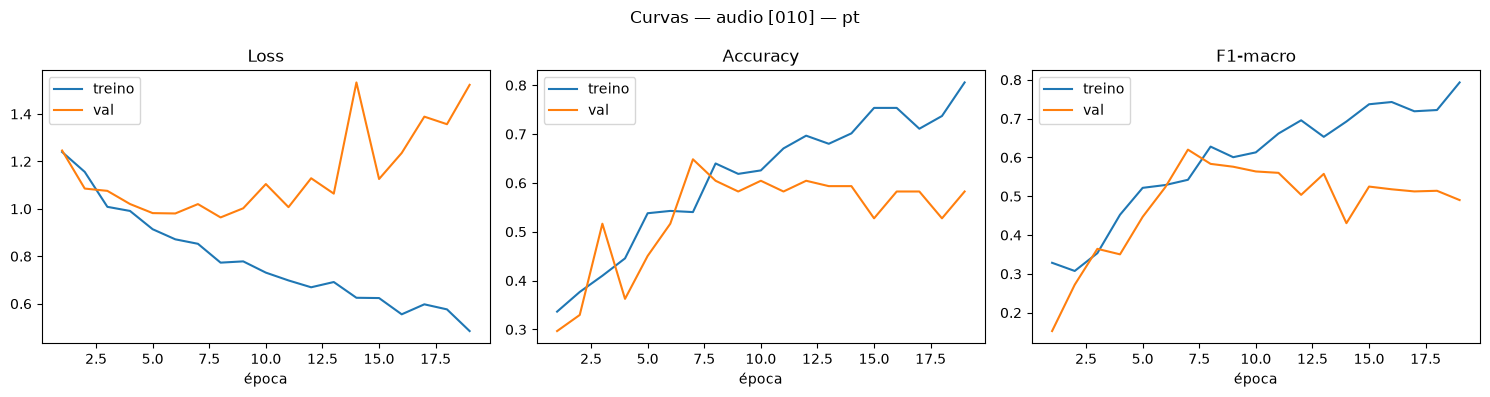

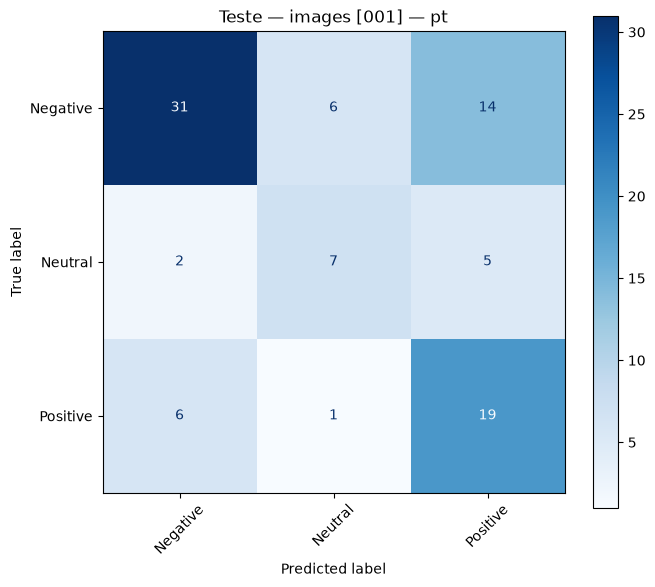

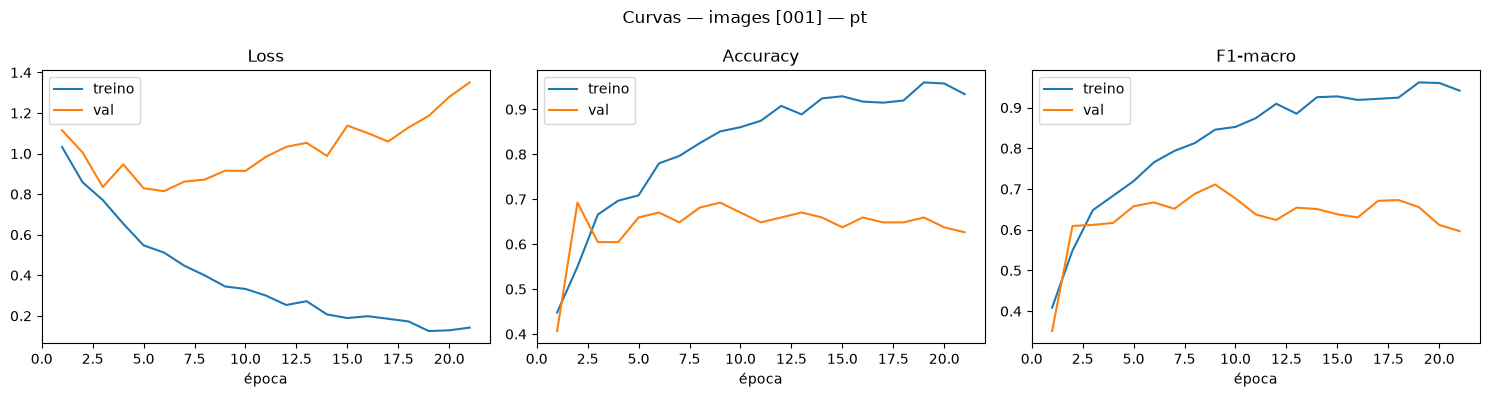

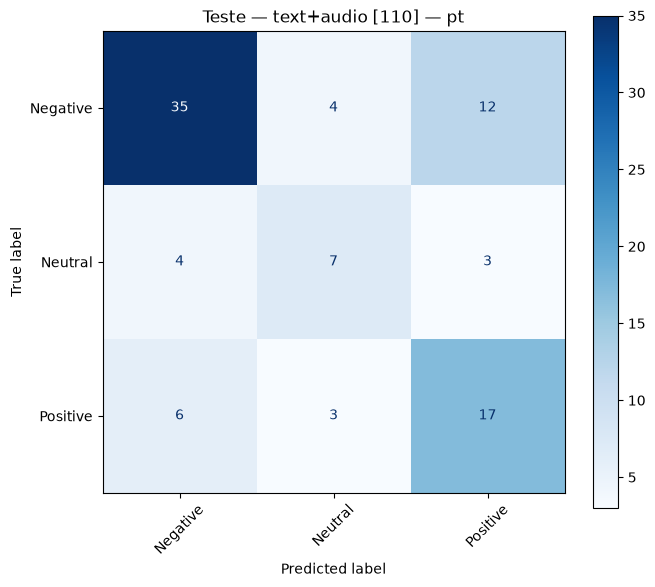

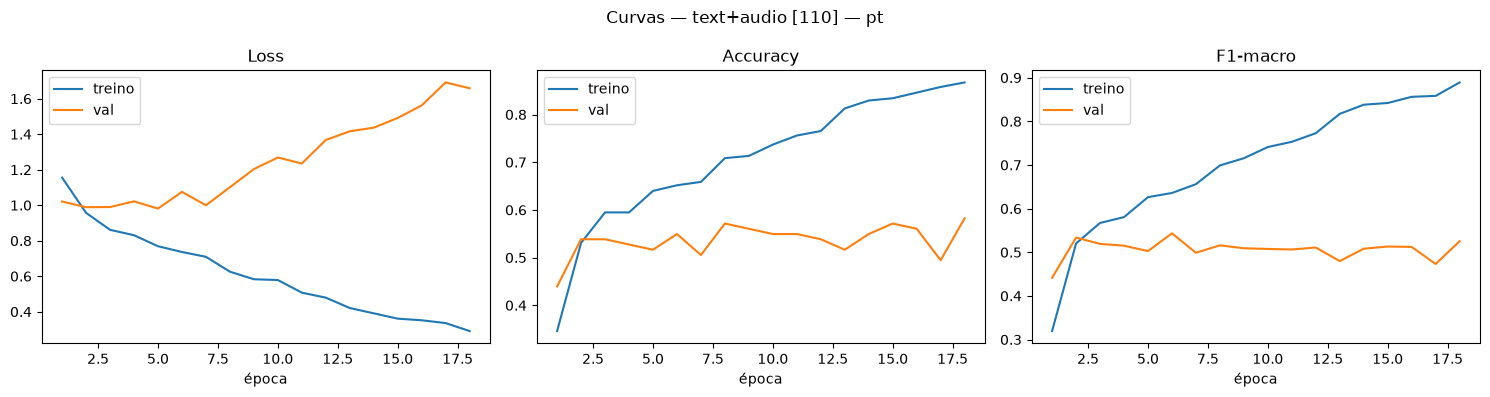

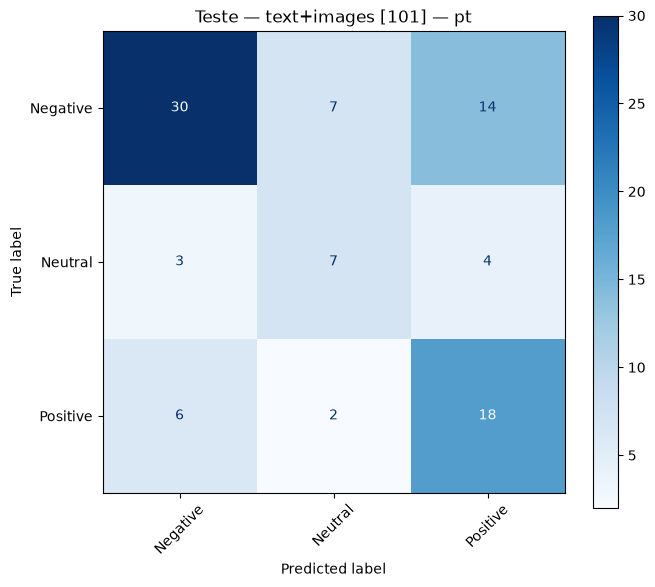

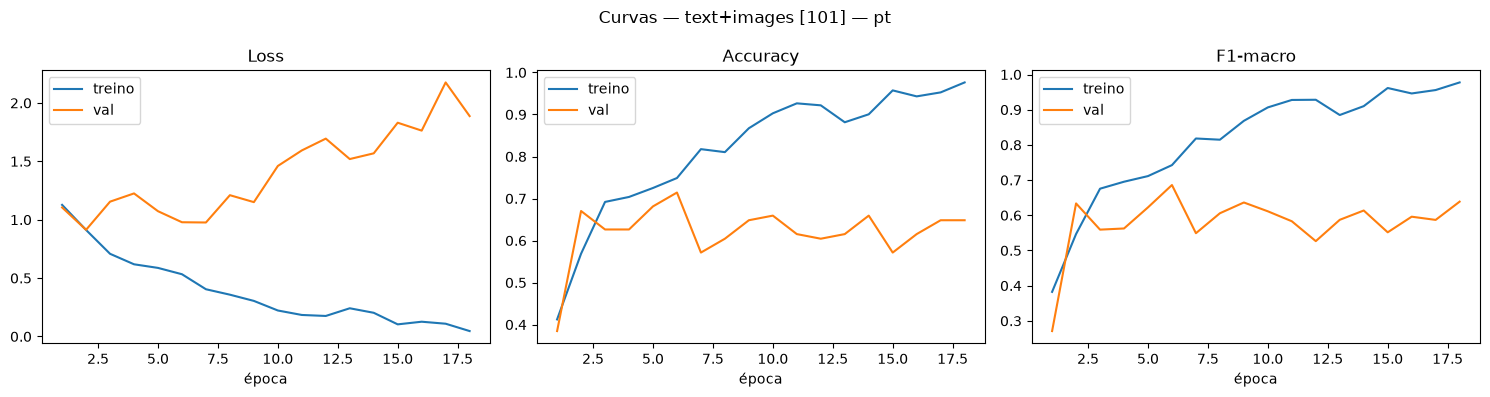

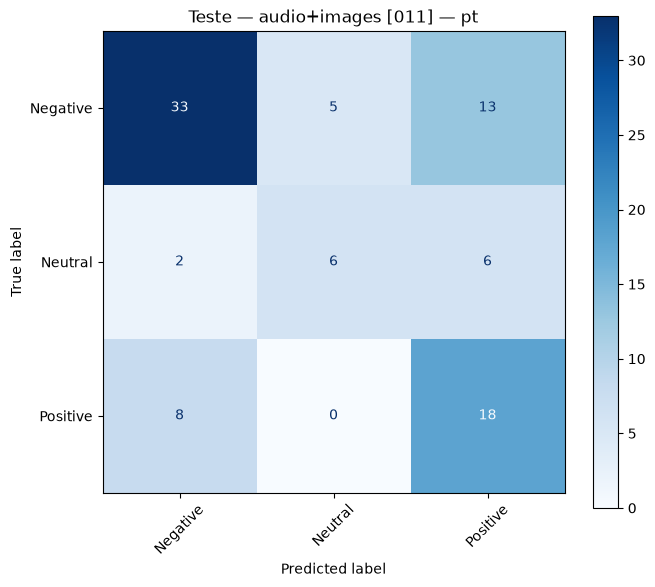

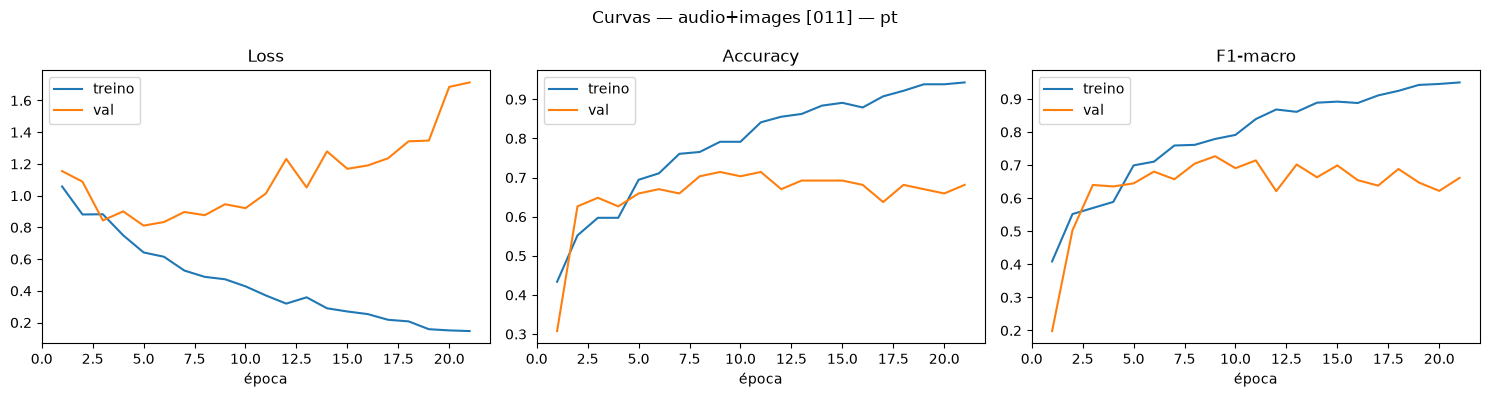

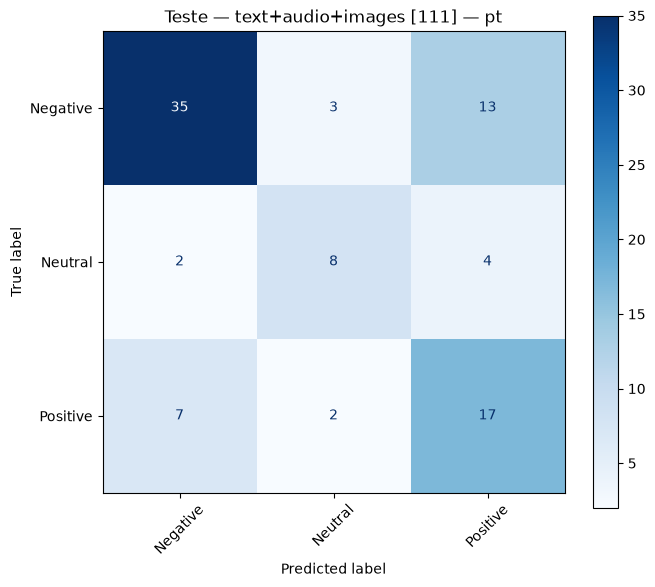

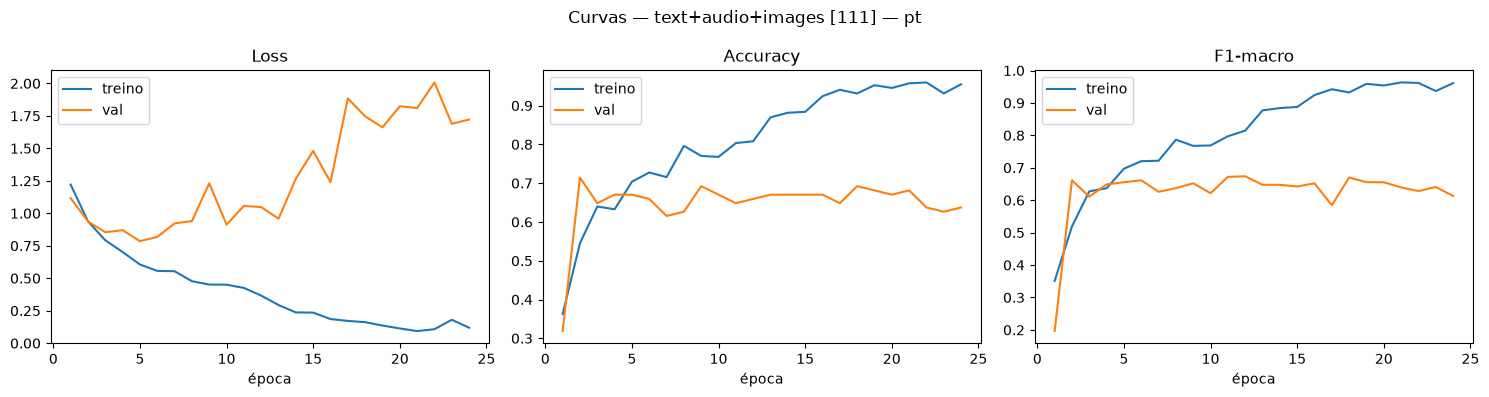

In [17]:
# Gráfico de barras comparando as combinações (quando há mais de uma)
if len(results_table) > 1:
    fig, ax = plt.subplots(figsize=(9, 4))
    xs = range(len(results_table))
    ax.bar(xs, results_table["test_f1_macro"])
    ax.set_xticks(list(xs))
    ax.set_xticklabels(results_table["modalities"], rotation=30, ha="right")
    ax.set_ylabel("F1-macro (teste)"); ax.set_ylim(0, 1)
    ax.set_title(f"Ablação de modalidades — dataset {dataset}")
    for i, v in enumerate(results_table["test_f1_macro"]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
    plt.tight_layout()
    plt.show()

# Matriz de confusão e curvas de treino por combinação
for mask, d in detailed.items():
    plot_confusion(d["y_true"], d["y_pred"], LABEL_NAMES, f"Teste — {d['name']} [{mask}] — {dataset}")
    plot_history(d["history"], f"Curvas — {d['name']} [{mask}] — {dataset}")